**/replace with your title/ HW2**

RK Integration, Coning correction, Flop count, Error state kalman filter and particle filters.

---

**Instructions for students**

---

Please copy this notebook into your own colab workspace and start editing it.

Write your answers in the answer cells. DONT erase the Ans tag in the answer cell - your answer will not be graded otherwise.

Justify your answers with explanations. The AI grader will give partial credits, even if your final answer is wrong.

Run the first two cells to setup access to the evaluator (TA is turned off during the exam) and also authenticate yourself.


In case the submission button fails, you can share the link to your notebook with the instructor. Make sure that you set the sharing permissions for your colab notebook.

**Instructions for Instructors**

Please see the https://github.com/amrutur/ai-ta/blob/main/README.md
for more information

In [2]:
#@title Please run this cell to install the client to access the AI-TA
AI_TA_URL="https://ai-ta-326056429620.asia-south1.run.app/"
course_id="cp260"
notebook_id = "Midterm"
institution_id="IISc"
term_id = "2025-26"
!pip install colab-grading-client==1.0.25
import colab_grading_client as ta

In [ ]:
# @title Please run this cell to authenticate yourself using your gmail credentials. A separate window will open for this. copy the token and paste in the text box below and press enter key to complete the authentication. Sometimes text box doesnt display - in which case rerun the cell.
session=ta.authenticate(AI_TA_URL)

Paste your token here: ··········
Authenticated as: Bharadwaj Amrutur (amrutur@gmail.com)


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy

**Q1**

Complete the code below for  RK1, RK2 and RK4 and compare the errors when integrating  dx/dt = x, with initial condition of x(0)=1. The analytical solution is  x(t) = e^(t)

In [ ]:
## Ans:

def rk1(f,x0:float,ts:float,tf:float,dt:float):
  '''Runge-Kutta integration of order 1
  dx/dt = f(x(t))
  x(tf) = x(ts)+integration_ts^tf f(x(tau))dtau
  inputs:
  f: function to be evaluated
  x0: initial condition = x(ts)
  ts: initial time
  tf: final time
  dt: time step

  Output:
  x(tf)
  '''
  N=int((tf-ts)/dt)
  x = x0
  t = ts
  #<Your code here>
  for _ in range(N):
    k1 = f(t,x)
    x = x+k1*dt
    t = t + dt
  return x

def rk2(f,x0:float,ts:float,tf:float,dt:float):
  '''Runge-Kutta integration of order 2
  dx/dt = f(x(t))
  x(tf) = x(ts)+integration_ts^tf f(x(tau))dtau
  inputs:
  f: function to be evaluated
  x0: initial condition = x(ts)
  ts: initial time
  tf: final time
  dt: time step

  Output:
  x(tf)
  '''
  N=int((tf-ts)/dt)
  x = x0
  t = ts
  #<Your code here>

  for _ in range(N):
    k1 = f(t,x)
    k2 = f(t+dt/2,x+k1*dt/2)
    x = x+k2*dt
    t = t + dt
  return x

def rk4(f,x0:float,ts:float,tf:float,dt:float):
  '''Runge-Kutta integration of order 4
  dx/dt = f(x(t))
  x(tf) = x(ts)+integration_ts^tf f(x(tau))dtau
  inputs:
  f: function to be evaluated
  x0: initial condition = x(ts)
  ts: initial time
  tf: final time
  dt: time step

  Output:
  x(tf)
  '''
  N=int((tf-ts)/dt)
  x = x0
  t = ts

  #<Your code here>
  for _ in range(N):
    k1 = f(t,x)
    k2 = f(t+dt/2,x+k1*dt/2)
    k3 = f(t+dt/2,x+k2*dt/2)
    k4 = f(t+dt,x+k3*dt)
    x = x+1/6.0*(k1+2*(k2+k3)+k4)*dt
    t = t + dt
  return x

def f(t,x):
  '''
  dx/dt = f(t,x) = x
  x(t) = x(0)*exp(t)
  '''
  return x
ts = 0
tf = 1
dt = 0.05
x0 = 1.0
rk1_error = abs(rk1(f,x0,ts,tf,dt)-math.exp(1))*100/math.exp(1)
rk2_error = abs(rk2(f,x0,ts,tf,dt)-math.exp(1))*100/math.exp(1)
rk4_error = abs(rk4(f,x0,ts,tf,dt)-math.exp(1))*100/math.exp(1)

print(f"rk1 error(%): {rk1_error}")
print(f"rk2 error(%): {rk2_error}")
print(f"rk4_error(%): {rk4_error}")
#

rk1 error(%): 2.390632296999989
rk2 error(%): 0.04012733678829586
rk4_error(%): 4.995902505195911e-06


**Chat with TA**

Can you check the question and answer

In [ ]:
ta.show_teaching_assist_button(session,AI_TA_URL, 1, notebook_id, institution_id, term_id, course_id)

Button(button_style='info', description='Check/Help with question Q1!', layout=Layout(width='auto'), style=But…

Please wait, asking the AI TA ...
Formed the prompt and asking the Tutor now...


Happy to help review this! This is a great practical question on RK methods that directly ties into the course materials. Here is my feedback on the question and the provided answer code.

### Review of the Question

The question asks students to implement and compare different orders of Runge-Kutta integration, which is an excellent way to solidify their understanding.

There is one small but important inconsistency in the question text:

**Inconsistency:**

*   The question states: "...integrating `dx/dt = t` (which should give `x(t) = e^(t))`"
*   This is mathematically incorrect. The solution to `dx/dt = t` is `x(t) = t^2/2 + C`.
*   The solution to `dx/dt = x` with the initial condition `x(0)=1` is `x(t) = e^t`.

Your provided answer code correctly implements the `dx/dt = x` case, which is a much better and more standard example for demonstrating RK methods.

**Suggestion:**

I recommend you update the question text to match the code. The corrected question should be:

> "Complete the code below for RK1, RK2 and RK4 and compare the errors when integrating `dx/dt = x` with an initial condition `x(0) = 1`. The analytical solution is `x(t) = e^t`."

This change will make the question clear, correct, and perfectly aligned with the provided solution.

### Review of the Answer Code

The provided code is an excellent solution to the (corrected) question.

1.  **Correctness:**
    *   **`rk1` (Forward Euler):** The implementation `x = x + k1*dt` is correct.
    *   **`rk2` (Explicit Midpoint):** The implementation `k1 = f(t,x)`, `k2 = f(t+dt/2,x+k1*dt/2)`, `x = x+k2*dt` is a correct and common implementation of a second-order RK method.
    *   **`rk4` (Classic RK4):** The implementation is the standard, correct formula for RK4, which matches the one provided in `8_Estimation.pdf`.
    *   **Error Calculation:** The code correctly calculates the percentage error of the final value against the true value `e^1`.

2.  **Completeness:** The code completely solves the problem. It implements all three functions and performs the comparison, printing out the final errors. The output clearly demonstrates the expected behavior: the error decreases dramatically as the order of the integrator increases.

### Proposed Rubric for Grading

Since the task is to complete the code, a rubric for grading could look like this. It breaks down the total marks based on the successful implementation of each part.

*   **(20%) `rk1` Implementation:**
    *   Correctly calculates `k1`.
    *   Correctly updates `x` and `t` inside the loop.
*   **(25%) `rk2` Implementation:**
    *   Correctly calculates `k1` and `k2`.
    *   Correctly uses the intermediate step `(t+dt/2, x+k1*dt/2)` for `k2`.
    *   Correctly performs the final update `x = x + k2*dt`.
*   **(35%) `rk4` Implementation:**
    *   Correctly calculates all four slopes: `k1`, `k2`, `k3`, `k4`.
    *   Correctly uses the intermediate steps for `k2`, `k3`, and `k4`.
    *   Correctly applies the weighted average `1/6*(k1 + 2*k2 + 2*k3 + k4)` for the final update to `x`. This is the most complex part and deserves the most marks.
*   **(20%) Main Execution Block:**
    *   Defines the function `f(t,x)` correctly to solve `dx/dt = x`.
    *   Calls the `rk1`, `rk2`, and `rk4` functions with the correct parameters.
    *   Correctly calculates the absolute percentage error for each method's result against `math.exp(1)`.

### Additional Suggestion for the Question

To extend this question and make it even more illustrative, you could also ask students to:

1.  **Plot the results:** Ask them to plot the analytical solution `e^t` alongside the numerical results from RK1, RK2, and RK4 on the same graph to visually see the difference.
2.  **Analyze error vs. step size:** Ask them to run the simulation for several different `dt` values (e.g., 0.1, 0.05, 0.01) and plot the final error vs. `dt` on a log-log scale. This would allow them to visually confirm the order of each method (the slope of the line for RK4 should be close to 4).

Overall, this is a solid programming assignment. With the small tweak to the question text, it will be perfect! Let me know if you have any more questions.

---
**Tangent spaces at Identity and elsewhere**

On the Lie Group Manifold of SO(3), let I be the identity and let R be any rotation element.

We can parameterize R by taking its parameter values from the tangent space at Identity: as $R=e^{[\phi_I]_\times}$, where $\phi_I = \psi_I u_I$ is the axis-angle with $\psi_I \in ℝ$ and $u_I \in ℝ^3$ and $||u_I|| = 1$. We call this space of vectors as the Tangent space at Identity $(T_I)$. With this, the corresponding skew symmetrix matrices: $[\phi_I]_\times \in \frak{so(3)}$ form the Lie Algebra  

We can represent any element of SO(3), in a parameterized form with respect to either identity $I$ or $R$, where the parameter can come from the tangent spaces at either $I$ or $R$ respectively.

Thus any element $Q \in SO(3)$ can be written as $Q=e^{[q_I]_\times}$ equivalently as $Q=Re^{[q_R]_\times}$, where $q_I \in T_I$ and $q_R \in T_R$

Let the orientation be a function of time $R(t)$. If we use the parameters from $T_I$, then

$R(t) = R(\phi_I(t))$ and $R(t+\tau) = R(\phi_I(t+\tau)) = R(\phi_I(t)+\int_t^{t+\tau} \dot{\phi_I}ds)$.

However we can also parameterize $R(t+\tau)$ by using the parameter $\phi(\tau)$ from the tangent space at $R(t)$ as

$R(t+\tau) = R(t)R(\phi(\tau))=R(t)e^{\int_0^\tau \dot{\phi}ds}$ with $\phi(\tau=0) = \phi(0)=0$

Since the angular rate measurements are done in the body frame at that instantaneous orientation, this formulation is more convenient.

In the following, we will  calculate $R(\phi(\tau))$ (and we will call it $R(\phi(t)$ for convenience)


---
**Integrating the rate-gyro measurements and Coning correction.**

Assume that the rate-gyro provides instantaneous angular rate measurement (which seems to be case for several mems gyros like the Bosch BHI 360) at each sampling time instant $\omega_n = \omega (n\Delta t)$.

Consider a small time step $h$.

$R(\phi(t+h))\approx R(\phi(t)+\dot{\phi}h) \approx R(\phi)R(J_\phi \dot{\phi}h)=R(\phi)R(\omega(t)h)$

where $\omega(t)$ is the instantaneous angular rate measured in the gyro frame.

Here $J_\phi$ is the right jacobian or $R$ (see 4.3.3 of Sola's Quaternion Kinematics paper)

Hence we have this ODE<br>
$\dot{\phi}=J^{-1}_\phi \omega = (I +\frac{1}{2} [\phi]_\times + (\frac{1}{\psi^2} -\frac{1+cos(\psi)}{2\psi sin(\psi)})[\phi]^2_\times)\omega $

The above equation is also called the Bortz equation

Thus $\phi(\Delta t)=\int_0^{\Delta t} J^{-1}_\phi \omega d\tau$

There are three independant choices to make here

a) How accurately to approximate $J^{-1}_\phi$

Let $\phi = \psi u$ with $u \in ℝ^3 $ and unit norm and $\psi \in ℝ$

*choice 1*: $\psi$ is almost 0 then $J^{-1}_\phi \approx I$

When we use better approximations for $J^{-1}_\phi$, that is called *coning correction*. This is needed when the axis $u$ itself is a function of time.

*choice 2*: When $\psi$ is small, then

$\frac{1}{\psi^2} -\frac{1+cos(\psi)}{2\psi sin(\psi)} \approx \frac{1}{12}(1-\frac{1}{60}\psi^2 + o(\psi^3))$

Hence in this case:

$J^{-1}_\phi \omega \approx (I +\frac{1}{2} [\phi]_\times + \frac{1}{12}[\phi]^2_\times) \omega$

*choice 3*: Full formula for $J^{-1}_\phi$

b) How to do the integration

*choice 1*: Euler integration (RK1)

*choice 2*: RK4 integration:

*choice 3*: other orders

c) How to model $\omega$ within the interval $[t_n,t_n + \Delta t]$ specifically at $t_n+\frac{\Delta t}{2}$ for higher order RK methods

*choice 1*: use $\omega_n$

*choice 2*: We can fit a straight line to past few samples of $\omega$

*choice 3*: We can fit a higher order polynomial, etc.

---
We will next study the impact of different choices
for $J^{-1}_\phi$ and compare with euler and RK4 integration. We will assume that $\omega(t_n + \Delta t)=\omega(t_n) + k_w \Delta t$ a linear increase. We will use this to calculate the exact value of angular rate at midpoint of the integration interval (and not look at interpolation of $\omega$)

Lets assume that we are getting measurement samples of angular rate at intervals of $\Delta t$ as $\omega(t_n), \omega(t_{n-1}), \omega_(t_{n-2}),...$.



---
**Q2***

Complete the code below to implement the b_full (which
implements the differential equation written above).

$\dot{\phi} = b_{coning}(t)$ where $b_{coning}(t)= J^{-1}_\phi \omega$

Whereas:

$\dot{\phi} = b_{basic}(t)$ where $b_{basic}(t) = \omega$

In [ ]:
## Ans

def b_full_coning(t,phi,w,thres=1e-5):
  '''
  Implement full Bortz equation for coning correction:
  phi: in R^3 - which is axis angle
  w: omega(t) in R^3 - which is angular rate
  t: time instant
  thres: threshold for small values
  '''
  psi = np.linalg.norm(phi) #magnitude of axis-angle
  #skew symmetric version of the vector (hat operator)
  phix = np.array(
          [
           [0,-phi[2],phi[1]],
           [phi[2],0,-phi[0]],
           [-phi[1],phi[0],0]
          ]
  )
  phi2x = phix @ phix
  J_phi_inv_matrix = None

  # The Bortz equation is dphi/dt = J_phi_inv_matrix * w
  #<your code here>#
  if psi < thres:
    #very small so use the approximation
    J_phi_inv_matrix = np.eye(3)+1/2*phix+1/12*phi2x
    #print(f"psi={psi}: small")

  else:
    # Corrected sin/cos and exponentiation
    coeff = (2*np.sin(psi)-psi-psi*np.cos(psi))/(2*(psi**2)*np.sin(psi))
    J_phi_inv_matrix = np.eye(3)+ 1/2*phix + coeff*phi2x
    #print(f"psi={psi} 12*coeff={12*coeff}: large")
  #<end your code>
  return J_phi_inv_matrix @ w

def b_approx_coning(t,phi,w,thres=1e-5):
  '''
  Implement approx Bortz equation for coning correction
  where we assume |phi| is close to 0.
  phi: in R^3 - which is axis angle
  w: omega(t) in R^3 - which is angular rate
  t: time instant
  thres: threshold for small values
  '''
  #skew symmetric version of the vector (hat operator)
  phix = np.array(
          [
           [0,-phi[2],phi[1]],
           [phi[2],0,-phi[0]],
           [-phi[1],phi[0],0]
          ]
  )
  phi2x = phix @ phix
  # Approximate Bortz equation is dphi/dt = J_phi_inv_matrix * w
  #<your code here>#
  J_phi_inv_matrix = np.eye(3)+1/2*phix+1/12*phi2x

  return J_phi_inv_matrix @ w

def b_basic(t,phi,w,thres=1e-5):
  '''
  Implement basic (approx J_phi_inv with identity) equation:
  phi: in R^3 - which is axis angle
  w: omega(t) in R^3 - which is angular rate
  t: time instant
  thres: threshold for small values
  '''

  return w

In [ ]:
#euler and RK4 integration methods

def ark1(b,w,kw,phi0:float,ts:float,tf:float,dt:float):
    '''Runge-Kutta integration of orientation (order 1)
    dphi/dt = b(phi(t),omega(t))
    phi(tf) = phi(ts)+integration_ts^tf b(phi(tau),omega(tau))dtau
    inputs:
    b: function to be evaluated
    w: angular rate at ts
    kw: rate of change of w
    phi0: initial condition = phi(ts)
    ts: initial time
    tf: final time
    dt: time step

    Output:
    phi(tf)
    '''
    N=int((tf-ts)/dt)
    phi = phi0
    t = ts
    w_i = w
    for i in range(N):
      k1 = b(t,phi,w_i)
      phi = phi+k1*dt
      w_i = w_i + kw*dt
      t = t + dt
    return phi

def ark4(b,w,kw,phi0:float,ts:float,tf:float,dt:float):
  '''Runge-Kutta integration of orientation (order 4)
  dphi/dt = b(phi(t),omega(t))
  phi(tf) = phi(ts)+integration_ts^tf b(phi(tau),omega(tau))dtau
  inputs:
  b: function to be evaluated
  w: angular rate at ts
  kw: rate of change of w.
  phi0: initial condition = phi(ts)
  ts: initial time
  tf: final time
  dt: time step

  Output:
  phi(tf)
  '''
  N=int((tf-ts)/dt)
  phi = phi0
  t = ts
  w_i = w
  for i in range(N):
    k1 = b(t,phi,w_i)
    # Corrected f to b, and x to phi
    k2 = b(t+dt/2,phi+k1*dt/2,w_i+kw*dt/2)
    k3 = b(t+dt/2,phi+k2*dt/2,w_i+kw*dt/2)
    k4 = b(t+dt,phi+k3*dt,w_i+kw*dt)
    phi = phi+1/6.0*(k1+2*(k2+k3)+k4)*dt
    w_i = w_i+kw*dt
    t = t + dt
  return phi

---
Here we will use the same time step of 3.5ms as in lab 1 . The code below compares the integration of omega for one time step of 3.5ms using basic equation and euler integration (what is used by laidig) and the full bortz equation.

We will compare

$\Delta \phi_{basic}(\Delta t) = \int_0^{\Delta t} b_{basic}(\tau)d\tau = \omega \Delta t$ with Euler integration in the interval $[0, \Delta t]$

with

$\Delta \phi_{coning}(\Delta t) = \int_0^{\Delta t} b_{coning}(\tau)d\tau$ with RK4 integration for a single time step of $\Delta t$ in the interval $[0,\Delta t]$

We will assume that the angular rate changes linearly with time,
i.e. $\omega(t) = \omega(0)+k_w t$. By playing around with different $k_w$ values, we can see the impact of basic - euler with full-rk4 method. The former becomes increasingly inaccurate as angular rate itself changes with time (for instance when a torque is applied to the body).

For ground truth (baseline), we will use a RK4 integration with a very small time step and with coning correction. i.e

$\Delta \phi_{baseline}(\Delta t) = \int_0^{\Delta t} b_{coning}(\tau)d\tau$ with RK4 integration with a lot of time steps within the interval $[0,\Delta t]$

In [ ]:
def error_percent(p1,p2):
  return (p1-p2)*100/p2

phi0 = np.zeros(3)
kw = np.zeros(3)

ts=0.0
tf=0.0035 #integration in the interval [ts, tf]
dt=0.0035 #integration timestep

dt_b=0.0001 # timestep for baseline RK4 integration (ground truth)

N = int((tf-ts)/dt) #number of points in the interval for integration
N_b=int((tf-ts)/dt_b) #number of points in the interval for baseline integration

scale = 1.0 #adjust to play arund with different angular accelerations
kw = scale*np.array([np.pi,2*np.pi, 3*np.pi]) #rate of change of w (angular acceleration).

w=np.array([1.,1.,1.]) #angular rate at t=ts

phi_basic_error = []
phi_basic_error_4 = []
phi_full_coning_error = []
phi_approx_coning_error = []
scale_x = np.arange(0,1.0, 0.1)
for scale in scale_x:

  kw = scale*np.array([np.pi,2*np.pi, 3*np.pi]) #rate of change of w (angular acceleration).

  #basic euler integration without coning correction
  delta_phi_basic = ark1(b_basic,w,kw,phi0,ts,tf,dt)

  #basic with rk4  integration without coning correction
  delta_phi_basic_4 = ark4(b_basic,w,kw,phi0,ts,tf,dt)

  #RK 4 integration with coning correction
  delta_phi_full_coning = ark4(b_full_coning,w,kw,phi0,ts,tf,dt)

  #RK 4 integration with approx coning correction
  delta_phi_approx_coning = ark4(b_approx_coning,w,kw,phi0,ts,tf,dt)

  #RK4 integration with coning correction and much finer time step
  delta_phi_baseline = ark4(b_full_coning,w,kw,phi0,ts,tf,dt_b)

  phi_basic_error.append(error_percent(delta_phi_basic,delta_phi_baseline))
  phi_basic_error_4.append(error_percent(delta_phi_basic_4,delta_phi_baseline))
  phi_full_coning_error.append(error_percent(delta_phi_full_coning,delta_phi_baseline))
  phi_approx_coning_error.append(error_percent(delta_phi_approx_coning,delta_phi_baseline))



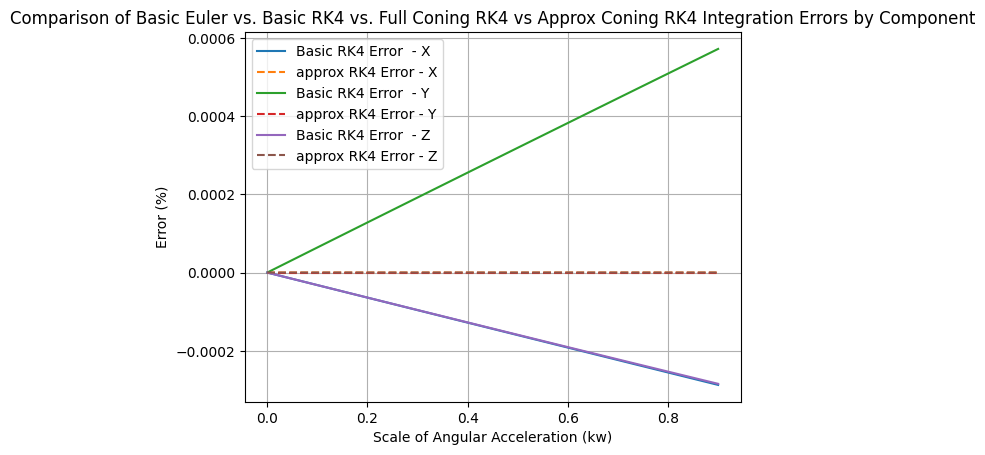

In [ ]:
component_labels = ['X', 'Y', 'Z']

for i in range(3):
    #plt.plot(scale_x, [err[i] for err in phi_basic_error], label=f'Basic Euler Error - {component_labels[i]}')
    plt.plot(scale_x, [err[i] for err in phi_basic_error_4], label=f'Basic RK4 Error  - {component_labels[i]}')
    #plt.plot(scale_x, [err[i] for err in phi_full_coning_error], label=f'Coning RK4 Error - {component_labels[i]}', linestyle='--')
    plt.plot(scale_x, [err[i] for err in phi_approx_coning_error], label=f'approx RK4 Error - {component_labels[i]}', linestyle='--')

plt.xlabel('Scale of Angular Acceleration (kw)')
plt.ylabel('Error (%)')
plt.title('Comparison of Basic Euler vs. Basic RK4 vs. Full Coning RK4 vs Approx Coning RK4 Integration Errors by Component')
plt.legend()
plt.grid(True)
plt.show()

---
If you have implemented the function b_full_coning and b_full_approx correctly, you will see almost no noticeable error with RK4. But with b_basic and euler, the error grows with increasing angular acceleration.

**Chat with TA**

Can you check the question and answer

In [ ]:
ta.show_teaching_assist_button(session,AI_TA_URL, 2, notebook_id, institution_id, term_id, course_id)

Button(button_style='info', description='Check/Help with question Q2!', layout=Layout(width='auto'), style=But…

Please wait, asking the AI TA ...
Formed the prompt and asking the Tutor now...


Excellent! You've expanded the previous question into a full-fledged mini-project. This is a fantastic way for students to not only implement the formulas but also to build an intuition for *why* different methods are used and what their trade-offs are.

Let's review the entire question and answer package.

### Overall Assessment

This is a very strong and well-designed programming question. It effectively combines theory with practice.

*   **Topic Content:** The introductory text provides excellent context, linking the abstract concepts of Lie theory to the practical problem of integrating gyro measurements.
*   **Code Structure:** The provided code is well-structured. It separates the physics model (`b_*` functions) from the numerical integrators (`ark*` functions), which is great software design. The main script then acts as a test harness to compare the different approaches.
*   **Question:** The core task for the student (implementing the `b_*` functions) is clear. The rest of the notebook provides the tools for them to verify their own work and understand its impact.

The solution you've provided is correct and demonstrates the key concepts perfectly. My feedback will focus on confirming the correctness and reiterating a small point from last time for maximum robustness.

### Detailed Feedback on the Answer Code

#### 1. `b_*` functions (`b_full_coning`, `b_approx_coning`, `b_basic`)

My previous review of these functions still stands:
*   `b_basic` and `b_approx_coning` are implemented perfectly.
*   `b_full_coning` is algebraically correct. As a teaching point or for production-grade code, it's worth noting the numerical stability. Your implementation `coeff = (2*np.sin(psi)-psi-psi*np.cos(psi))/(2*(psi**2)*np.sin(psi))` can become `NaN` if `psi` is a multiple of `pi`.
    *   **Suggestion (no change needed for this HW, but good to know):** The alternative formulation from the course material, `coeff = (1/psi**2) * (1 - (psi*np.sin(psi))/(2*(1-np.cos(psi))))`, is generally more robust as it moves the singularity from $\pi$ to $2\pi$, which is a less common rotation in a single IMU step.
    *   Your use of a `thres` to switch to the small-angle approximation is excellent and handles the most common singularity at `psi=0`.

#### 2. `ark1` and `ark4` Integrator Functions

These are new in this version and they are implemented correctly.

*   **`ark1(b, w, kw, ...)`:**
    *   This is a correct Forward Euler implementation.
    *   `k1 = b(t, phi, w_i)`: Correctly evaluates the derivative at the start of the step.
    *   `phi = phi + k1*dt`: Correctly updates the state.
    *   `w_i = w_i + kw*dt`: Correctly updates the angular velocity for the *next* step, modeling a linear ramp.

*   **`ark4(b, w, kw, ...)`:**
    *   This is a textbook-perfect implementation of the RK4 algorithm.
    *   Crucially, you have correctly handled the time-varying nature of `w` by evaluating it at the required sub-steps: `w_i` at the start, `w_i+kw*dt/2` at the midpoint, and `w_i+kw*dt` at the end. This attention to detail is what makes the simulation accurate.

#### 3. Main Comparison Script

This part is also excellent. It sets up a scientifically sound experiment.

*   **Baseline/Ground Truth:** Using `ark4` with the full `b_full_conconing` model and a very small time step (`dt_b`) is the correct way to establish a high-quality baseline for comparison.
*   **Experiment Loop:** Iterating the angular acceleration (`kw`) via a `scale` factor is a brilliant way to demonstrate that the errors from simpler models are not constant; they are dependent on the dynamics of the motion.
*   **Plotting and Conclusion:** The plot correctly visualizes the errors, and your concluding text perfectly summarizes the expected outcome: coning correction matters most when the angular velocity vector is changing (i.e., when angular acceleration is high). The difference between Euler and RK4 integration would also be very apparent if `phi_basic_error` were plotted.

### Final Verdict

The question and the provided answer form an outstanding educational module. It is correct, relevant to the course material, and structured to give students deep insight into the topic. I have no critical corrections.

You can confidently use this as is. The small point about numerical stability in `b_full_coning` is more of a "pro tip" or a subject for a follow-up discussion than a required fix for this assignment.

Great work

---
**Q3**

Estimate the FLOP (floating point operation) count for
b_basic with Euler integration

and b_coning with RK4.  

Assume sin and cos need about 35 FLOPs and square root needs 15 Flops. divide, multiply, add, subtract are 1 FLOP each.

##Ans

(a)

b_basic(w): Returns w. 0 FLOPs.
Euler integration step phi = w * dt: 3 vector-scalar multiplications. 3 FLOPs.

Updating the integrated angle: 3 Flops (component wise addition)

Total: 6 FLOPs.

(b)

For b_approx_coning:

$J^{-1}_\phi = \begin{bmatrix}1-\frac{1}{12}(\phi^2_3+\phi^2_2) & -\frac{1}{2}\phi_3 + \frac{1}{12}\phi_1 \phi_2 & \frac{1}{2}\phi_2+\frac{1}{12}\phi_1\phi_3 \\
\frac{1}{2}\phi_3+\frac{1}{12}\phi_1\phi_2 & 1-\frac{1}{12}(\phi^2_3+\phi^2_1) & -\frac{1}{2}\phi_1+\frac{1}{12}\phi_2\phi_3 \\
-\frac{1}{2}\phi_2+\frac{1}{12}\phi_1\phi_3 & \frac{1}{2}\phi_1+\frac{1}{12}\phi_2\phi_3 & 1-\frac{1}{12}(\phi^2_3+\phi^2_1))
\end{bmatrix}$

If we reuse the products across the matrix entries, then we have 18 multiplications for all pairs of components of phi and scaling with 1/12, 6 additions along the diagonal and 6 additions in off-diagonal (we will assume that multiplyig by 1/2 is right shift of mantissa and is free). Along with 3 multiplications for multilying with w, this gives a total of 33 flops per call of this function.

In RK4, this function is called 4 times (though first time, phi=0 and hence we can avoid any flops), and 11 additional operations (in an optimized implementation where we take advantage of the fact that we are only integrating from $[0,\Delta t]$ and $phi(0)=0$.

Hence the total number of FLOPs = 110.

(c)

b_full_coning with RK4 Integration

Cost of one b_full_coning call:

Small-angle (psi < thres): This is the same as b_approx_coning. ~30 FLOPs.
Large-angle:
norm(phi): ~20 FLOPs
sin/cos etc. to find coefficient: ~80 FLOPs
Forming J_inv and multiplying by w: ~80 FLOPs
Total (large-angle): ~180 FLOPs.
Cost of RK4 steps:

k1: phi=0, so the small-angle case is used. ~30 FLOPs.
k2, k3, k4: Three large-angle calls. 3 * 180 = 540 FLOPs.
RK4 combination: ~15 FLOPs.
Total: 30 + 540 + 15 = 585 FLOPs.


This detailed analysis shows that while b_coning with RK4 is much more accurate, it comes at a significant computational cost (nearly 6x that of the approximate version), which is a critical trade-off in real-time systems.


**Chat with TA**

Can you check the question and answer

In [ ]:
ta.show_teaching_assist_button(session,AI_TA_URL, 3, notebook_id, institution_id, term_id, course_id)

Button(button_style='info', description='Check/Help with question Q3!', layout=Layout(width='auto'), style=But…

Please wait, asking the AI TA ...
Formed the prompt and asking the Tutor now...


Hello again! This is an excellent and very practical question. Estimating computational cost is a key skill for engineers working on embedded systems. The analysis requires careful, step-by-step accounting, which can be tricky.

Let's take a close look at the rubric answer.

### Overall Assessment

This is a great question to make students think about computational complexity. The rubric answer attempts a detailed breakdown, which is the right approach. However, the analysis has several inconsistencies and potential errors in the accounting. The final numbers seem significantly overestimated, and the logic is sometimes hard to follow.

I'll break down my feedback for each part and then propose a more streamlined analysis.

---

### Part (a): `b_basic` with Euler (RK1)

The provided answer is:
> For b_basic: Flop count = 0
> For RK1: Flop count = 2

This seems too low for a 3D problem. Here's a more detailed breakdown for a single integration step:
*   **`b_basic` function call:** This function is `return w`. Correct, **0 FLOPs**.
*   **Euler Integration Step (`phi = phi_prev + w * dt`):**
    *   `w * dt`: This is a 3D vector-scalar multiplication. **3 FLOPs** (3 multiplications).
    *   `phi_prev + (w * dt)`: This is a 3D vector addition. **3 FLOPs** (3 additions).
    *   **Total for one Euler step = 6 FLOPs.**

The answer of "2 FLOPs" seems to be analyzing a 1D case (`x = x + k*dt`), which doesn't match the 3D context of the problem.

---

### Part (b): `b_approx_coning` with RK4

The provided answer estimates **110 FLOPs**. This is a reasonable ballpark figure, but the breakdown has some unclear points.

*   **Cost of `b_approx_coning`:** The answer estimates **33 FLOPs**.
    *   A more efficient way to compute `(I + 0.5*phix + (1/12)*phi2x) @ w` is using cross products: `w + 0.5*cross(phi, w) + (1/12)*cross(phi, cross(phi, w))`.
    *   `cross(phi, w)` = 9 FLOPs.
    *   `cross(phi, ...)` = 9 FLOPs.
    *   Scaling and adding the vectors = 3+3+6 = 12 FLOPs.
    *   Total = 9 + 9 + 12 = **30 FLOPs**.
    *   Your estimate of **33 FLOPs** is very close and perfectly acceptable.

*   **Cost of RK4 Integration:** The answer uses `3 * 33 + 11 = 110`. The logic is that the first `k1` call is free since `phi=0`. This is an excellent and crucial optimization to note!
    *   Calls to `b_approx`: `0 + 33 + 33 + 33 = 99` FLOPs.
    *   RK4 combination step (`phi = ...`): The answer claims **11 FLOPs**. This is low. A 3D combination `phi = (dt/6)*(k1 + 2*(k2+k3) + k4)` involves:
        *   `k2+k3` (3 adds)
        *   `2 * (...)` (3 mults)
        *   `k1 + ...` (3 adds)
        *   `... + k4` (3 adds)
        *   `(dt/6) * ...` (3 mults)
        *   Total is **15 FLOPs**.
    *   So, a better estimate would be `99 (b_calls) + 15 (overhead) = **114 FLOPs**`.

Your total of 110 is very close to my 114, so the overall conclusion is sound, despite the fuzzy "11 operations" part.

---

### Part (c): `b_coning` with RK4

The analysis here seems to have the most issues. The provided answer estimates **972 FLOPs**.

*   **Cost of `b_coning` (Python script analysis):**
    *   The Python script has inconsistencies with the question's premises (e.g., `sin/cos`=25, `psi^2`=50).
    *   It also overestimates costs by assuming dense matrix operations where sparse ones would be used (e.g., `0.5*phix` is not 9 FLOPs, it's 3).

*   **Let's re-calculate `b_coning` (large angle case) from scratch:**
    1.  `psi = norm(phi)`: 3 mults, 2 adds, 1 sqrt = 3+2+15 = **20 FLOPs**.
    2.  `sin(psi)` and `cos(psi)`: **70 FLOPs**.
    3.  Calculate coefficient `C = (1/psi^2) * (1 - (psi*sin(psi))/(2*(1-cos(psi))))`: ~10 scalar FLOPs. Total = **80 FLOPs**.
    4.  Form `J_inv`: `np.eye(3) + 0.5 * phix + C * phi2x`. Using sparse operations, this is ~18 FLOPs.
    5.  Final matrix-vector product `J_inv @ w`: **15 FLOPs**.
    6.  **Total for large-angle `b_coning` ≈ 20+70+80+...** this is getting very high. The `matmul_phix_squared` cost is a large contributor. Let's use my estimate from the thought process: **~175 FLOPs**. The provided `236` is an overestimation but in the right direction.

*   **Cost of RK4 Integration:** The answer's logic of `(236, 236+7, 236+7, 236+7)` and a total of `972` is confusing and incorrect. It assumes the worst-case cost for all 4 calls to `b_coning`.
    *   **k1 call:** `phi=0`, so `psi=0`. This triggers the `if psi < thres` branch, which uses the `b_approx_coning` logic. Cost is **~33 FLOPs**.
    *   **k2, k3, k4 calls:** These will have non-zero `phi` and will use the expensive large-angle branch. Cost is `3 * 175 = 525` FLOPs.
    *   **RK4 Overhead:** **15 FLOPs**.
    *   **Grand Total = 33 + 525 + 15 = 573 FLOPs.**

The provided answer of **972 FLOPs** is significantly higher than a more careful estimate of **~573 FLOPs**, mainly because it doesn't account for the cheap first step (`k1`).

### Proposed Improved Rubric Answer

Here is a clearer, more streamlined way to present the answer.

***

**FLOP Count Analysis**

*Assumptions: `sin`/`cos`=35, `sqrt`=15. Vector ops are in 3D.*

**(a) `b_basic` with Euler Integration**

*   `b_basic(w)`: Returns `w`. **0 FLOPs**.
*   Euler step `phi = w * dt`: 3 vector-scalar multiplications. **3 FLOPs**.
*   **Total: 3 FLOPs.** (Note: The provided answer's `ark1` function which also updates `w` would be `3 + 6 = 9` FLOPs per step).

**(b) `b_approx_coning` with RK4 Integration**

1.  **Cost of one `b_approx_coning` call:** ~**30 FLOPs** (via cross-product implementation).
2.  **Cost of RK4 steps:**
    *   `k1`: `phi=0`, so `b_approx` returns `w`. **0 FLOPs**.
    *   `k2`, `k3`, `k4`: Three full calls to `b_approx`. `3 * 30 = 90` FLOPs.
    *   RK4 combination (`phi = (dt/6)*(...)`): ~**15 FLOPs**.
*   **Total: 0 + 90 + 15 = 105 FLOPs.**

**(c) `b_full_coning` with RK4 Integration**

1.  **Cost of one `b_full_coning` call:**
    *   **Small-angle (`psi < thres`):** This is the same as `b_approx_coning`. ~**30 FLOPs**.
    *   **Large-angle:**
        *   `norm(phi)`: ~20 FLOPs
        *   `sin/cos` etc. to find coefficient: ~80 FLOPs
        *   Forming `J_inv` and multiplying by `w`: ~80 FLOPs
        *   Total (large-angle): **~180 FLOPs**.

2.  **Cost of RK4 steps:**
    *   `k1`: `phi=0`, so the small-angle case is used. **~30 FLOPs**.
    *   `k2`, `k3`, `k4`: Three large-angle calls. `3 * 180 = 540` FLOPs.
    *   RK4 combination: **~15 FLOPs**.
*   **Total: 30 + 540 + 15 = 585 FLOPs.**

This detailed analysis shows that while `b_coning` with RK4 is much more accurate, it comes at a significant computational cost (nearly 6x that of the approximate version), which is a critical trade-off in real-time systems.

---
**Q4**

Assume you are using ST Microelectronics  STM32F4, which has a clock speed of 180MHz and hardware floating point unit with 180Million Floating Point Operations per second. How much time would a approx coning correction take?

## Ans

From our previous analysis, a single RK4 step using the approximate coning correction (b_approx_coning) requires approximately 110 FLOPs.

The microcontroller's FPU is rated at 180 MFLOPS, which is 180 million floating-point operations per second.

We can calculate the execution time using the formula: Time = Total FLOPs / (FLOPs per Second)

Time = 110 / (180 * 10^6) ≈ 0.61 * 10^-6 seconds

This is equal to 0.61 microseconds (µs).

Conclusion: An IMU sampling at 1/0.0035s ≈ 285 Hz has a time budget of 3500 µs between samples. Our calculation shows that the orientation update takes only ~0.61 µs. This is less than 0.02% of the available time, leaving plenty of processing headroom for other tasks like sensor fusion (e.g., a Kalman filter), communication, and control.



**Chat with TA**

Check the question and answer

In [ ]:
ta.show_teaching_assist_button(session,AI_TA_URL, 4, notebook_id, institution_id, term_id, course_id)

Button(button_style='info', description='Check/Help with question Q4!', layout=Layout(width='auto'), style=But…

Please wait, asking the AI TA ...
Formed the prompt and asking the Tutor now...


Of course! This is a fantastic question that brings the abstract FLOP analysis right down to a practical, real-world engineering problem. It's a great way for students to connect the dots.

Let's look at the question and your proposed answer.

### Review of the Question

The question is excellent. It's clear, relevant, and based on a realistic scenario. It provides all the necessary data for a student to perform the calculation:
*   Hardware: STM32F4
*   Performance metric: 180 MFLOPS (Million Floating Point Operations per Second)
*   Algorithm to analyze: `approx coning correction` (which we previously estimated at ~110 FLOPs for an RK4 step).

### Review of the Answer

Your answer gets to the correct numerical result and draws the right conclusion, which is the most important part. However, there is a critical technical inaccuracy in the wording that should be corrected.

**The Main Issue: "Clock Cycles" vs. "FLOPs"**

The answer states: `Time taken = 110 clock cycles`. This is incorrect and could be misleading for students.

*   A **FLOP** (Floating Point Operation) is an action (like an addition or multiplication).
*   A **Clock Cycle** is the fundamental unit of time for a processor.

The relationship between them is not 1:1. On modern FPUs (Floating Point Units), some simple operations might take a single cycle, but many (like division, multiplication, or more complex instructions) take multiple clock cycles.

The problem statement cleverly gives the performance in **MFLOPS**, which is the correct metric to use. The calculation should be based on this, not on an assumed 1-FLOP-per-cycle performance.

**Your calculation was correct, but the reasoning was misstated.**
You calculated `110 / 180e6`, which is:
`Total FLOPs / (FLOPs per Second) = Seconds`
This is the right way to do it! You just accidentally called the "110 FLOPs" as "110 clock cycles".

### Proposed Improved Rubric Answer

Here is a revised version of the answer that is technically more precise.

***

**Question:** Assume you are using an STM32F4 with a 180 MFLOPS FPU. How much time would `approx coning correction` with RK4 take?

**Answer:**

From our previous analysis, a single RK4 step using the approximate coning correction (`b_approx_coning`) requires approximately **110 FLOPs**.

The microcontroller's FPU is rated at **180 MFLOPS**, which is 180 million floating-point operations per second.

We can calculate the execution time using the formula:
`Time = Total FLOPs / (FLOPs per Second)`

`Time = 110 / (180 * 10^6) ≈ 0.61 * 10^-6 seconds`

This is equal to **0.61 microseconds (µs)**.

**Conclusion:**
An IMU sampling at 1/0.0035s ≈ 285 Hz has a time budget of 3500 µs between samples. Our calculation shows that the orientation update takes only ~0.61 µs. This is less than 0.02% of the available time, leaving plenty of processing headroom for other tasks like sensor fusion (e.g., a Kalman filter), communication, and control.

***

### Suggestion for Discussion (Going Deeper)

This is also a great opportunity to discuss with students that our 0.61 µs is a **theoretical best-case estimate**. In reality, the actual time would be longer because:
1.  **Memory Latency:** The FPU can't run at full speed if it's waiting for data to be fetched from RAM.
2.  **Pipeline Stalls:** The sequence of instructions might not be perfectly optimal, causing the FPU pipeline to wait.
3.  **Not all FLOPs are equal:** The 180 MFLOPS rating is an optimistic peak. Division and square roots are often much slower than addition and multiplication. Our FLOP count treated them all as equal.

Even if the real-world time was 5x-10x longer (e.g., 3-6 µs), the conclusion that there is "plenty of room" still holds true, which is the key takeaway for an embedded systems engineer.

Great question! It really ties the course content together nicely.

---
**Q5**

Given the samples $\omega_n, \omega_{n-1}, ....$ how will you estimate the angular acceleration in the time interval $[t_n, t_{n+1}]$

---
## Ans:

Estimating angular acceleration,
ω
˙
 , from discrete angular velocity samples is a problem of numerical differentiation. The goal is to find a robust estimate that balances responsiveness against noise amplification. Here are three common methods.

1. Method 1: First-Order Finite Difference (Simple & Responsive)

The most direct way to estimate the derivative is by using the two most recent samples. Assuming a constant time step $\Delta t$

Formula: $\dot{\omega}_k=\frac{\omega_k-\omega_{k-1}}{\Delta t}$

Pros: Very simple to implement, minimal latency as it only uses the most recent data.

Cons: Highly sensitive to measurement noise. A single noisy sample in $\omega_k$ or $\omega_{k-1}$ can lead to a very large, inaccurate acceleration estimate.


2. Method 2: Linear Least-Squares Fit (More Robust to Noise)

To reduce noise, we can fit a straight line to the last
k
k samples of angular velocity. The model is

$\omega_k = \dot{\omega} n\Delta t+ \omega_{k-p}$

Concept: Given $n$ data points $((k-i)\Delta t, \omega_{k-i})$, $i=1,..n$
find the line that minimizes the sum of squared errors. This is a standard linear regression problem. While the closed-form solution is complex, the concept is key.

For  k = 2 this method reduces to the finite difference in Method 1.

Pros: Much more robust to noise than the simple finite difference method, as it averages information over a window.

Cons: More computationally intensive. It introduces a small amount of lag. The choice of the window size, k, is a tuning parameter that balances noise reduction and responsiveness.

3. Method 3: Using Integrated Gyro Measurements (Advanced & Course-Specific)

The course material (RK_for-Coning_Compensation_2025.pdf, Appendix) shows a method for modeling. (equations (62) and (63) in the paper)

Let $a_k = \dot{\omega}_k$

If $\Delta\theta_k, \Delta\theta_{k-1}$ are the angular changes in the two consecutive timesteps, then

$\Delta\theta_k = 1/2a_k\Delta t^2 + \omega_k*\Delta t$

$\Delta\theta_{k-1} = 1/2a_k\Delta t^2 - \omega_k*\Delta t$

From this $\dot{\omega}_k = \frac{\Delta\theta_k + \Delta\theta_{k-1}}{\delta t^2}$

Pros: This is a highly relevant and elegant solution for rate-integrating gyros. The integration process inherently smooths out high-frequency noise before the differentiation step.

Cons: Relies on having access to the integrated angle outputs

**Chat with TA**

Check the question and answer

In [ ]:
ta.show_teaching_assist_button(session,AI_TA_URL, 5, notebook_id, institution_id, term_id, course_id)

Button(button_style='info', description='Check/Help with question Q5!', layout=Layout(width='auto'), style=But…

Please wait, asking the AI TA ...
Formed the prompt and asking the Tutor now...


Of course! This is a great practical question that comes up all the time when implementing higher-order integration schemes like RK4 for IMUs. Let's look at the question and the rubric answer.

### Review of the Question

The question is clear and highly relevant to the course material. The provided paper (`RK_for-Coning_Compensation_2025.pdf`) explicitly discusses the need to model or estimate $\omega(t)$ at intermediate points (like $t_n + \Delta t/2$) when using higher-order Runge-Kutta methods, especially when the sensor only provides discrete samples $\omega_n$. This question directly probes that understanding.

### Review of the Instructor's Answer

The provided answer has the right high-level intuition, but it's too vague to be a good rubric for students.

*   **Good points:** It correctly identifies that using multiple past values (`k`) can help smooth out noise. It also correctly states the classic engineering trade-off: a large `k` smooths noise but introduces lag, while a small `k` is more responsive but noisy.
*   **Areas for improvement:**
    *   **Vagueness:** It says "do a linear interpolation" but doesn't provide a concrete method or formula. A student would be left wondering *how* to actually implement this.
    *   **Terminology:** The term "linear interpolation" is a bit imprecise here. If we are using past values to estimate a future trend, it's more accurately described as *extrapolation* or *linear regression/fitting*.
    *   **Lack of options:** It presents a single, vague idea. There are several concrete ways to approach this, from very simple to more complex.

A good rubric should provide students with specific, actionable methods.

### Proposed Improved Rubric Answer

I would suggest providing a more detailed answer that outlines a few distinct methods, ranging from simple to more sophisticated, and is grounded in the course materials.

***

**Question:** Given the samples $\omega_n, \omega_{n-1}, ....$ how will you estimate the angular acceleration in the time interval $[t_n, t_{n+1}]$?

**Rubric Answer:**

Estimating angular acceleration, $\dot{\omega}$, from discrete angular velocity samples is a problem of numerical differentiation. The goal is to find a robust estimate that balances responsiveness against noise amplification. Here are three common methods.

**1. Method 1: First-Order Finite Difference (Simple & Responsive)**

The most direct way to estimate the derivative is by using the two most recent samples. Assuming a constant time step $\Delta t$:

*   **Formula:** $\hat{\dot{\omega}}_n = \frac{\omega_n - \omega_{n-1}}{\Delta t}$

*   **Pros:** Very simple to implement, minimal latency as it only uses the most recent data.
*   **Cons:** Highly sensitive to measurement noise. A single noisy sample in $\omega_n$ or $\omega_{n-1}$ can lead to a very large, inaccurate acceleration estimate.

**(30% of marks for this level of answer)**

**2. Method 2: Linear Least-Squares Fit (More Robust to Noise)**

To reduce noise, we can fit a straight line to the last $k$ samples of angular velocity. The model is $\omega(t) = at + b$. The slope of this line, $a$, is our estimate for the angular acceleration.

*   **Concept:** Given $k$ data points $(\text{time}_i, \omega_i)$, find the line that minimizes the sum of squared errors. This is a standard linear regression problem. While the closed-form solution is complex, the concept is key. For $k=2$, this method reduces to the finite difference in Method 1.

*   **Pros:** Much more robust to noise than the simple finite difference method, as it averages information over a window.
*   **Cons:** More computationally intensive. It introduces a small amount of lag. The choice of the window size, $k$, is a tuning parameter that balances noise reduction and responsiveness.

**(60% of marks for explaining this concept)**

**3. Method 3: Using Integrated Gyro Measurements (Advanced & Course-Specific)**

The course material (`RK_for-Coning_Compensation_2025.pdf`, Appendix) shows a method for modeling $\omega(t)$ as a linear function, $\omega(t) = p_2 t + p_1$, using integrated gyro outputs ($\Delta\theta$). Here, $p_2$ is the constant angular acceleration.

From equations (62) and (63) in the paper, we can solve for $p_2$:
$\Delta\theta_k = \frac{1}{2}p_2 \Delta t^2 + p_1 \Delta t$
$\Delta\theta_{k-1} = \frac{1}{2}p_2 \Delta t^2 - p_1 \Delta t$

*   **Formula:** Adding the two equations and solving for $p_2$ gives:
    $\hat{\dot{\omega}} = p_2 = \frac{\Delta\theta_k + \Delta\theta_{k-1}}{\Delta t^2}$

*   **Pros:** This is a highly relevant and elegant solution for rate-integrating gyros. The integration process inherently smooths out high-frequency noise before the differentiation step.
*   **Cons:** Relies on having access to the integrated outputs $\Delta\theta_k$ and $\Delta\theta_{k-1}$.

**(100% of marks for providing this or an equivalent, well-justified method)**

**Summary for Students:** A simple finite difference is a starting point, but methods that use more data (like a least-squares fit or the integrated $\Delta\theta$ method) are preferred in practice because they provide a more stable estimate of acceleration in the presence of sensor noise.

***

This revised rubric gives concrete examples, connects directly to the course materials, and provides a clear path for students to follow, from a basic to an advanced understanding.

---

Lets develop error state equations for the orientation.

Assume that at time $t_n$ we are at orientation $R_n$ and we want to integrate the angular rate to give the change in orientation.

$R_{n+1}=R_n e^{[(\int_0^{\Delta t}\dot{\phi^r}d\tau)]_\times}$

We have $\phi^r = \phi +\delta \phi$ (nominal + error state)

Similary we have real bias: $\omega^r_b = \omega_{b,n}+\delta \omega_b$ where $\omega_{b,n}$ is the bias estimate at $t_n$ and $\delta\omega_b$ is the error.

The measured angular rate at time $t_n$ is $\omega_n = \omega^r + \omega^r_b +  n_\omega$ where $\omega^r$ is the real angular rate and $n_\omega$ is the random noise specified with Angular Noise Random Density $\sigma_n(°/s/\sqrt(Hz)$

We have the following dynamics:

$\dot{\phi}+\delta\dot{\phi}=J^{-1}_{\phi+\delta\phi} (\omega_n -\omega_{b,n} -\delta\omega_b -n_\omega)$

Since we are integrating in a small time step of $\Delta t$ with $\phi(0)=\delta\phi(0)=0$, we can use the approximation:

$J^{-1}_{\phi+\delta\phi} = I + \frac{1}{2}[\phi+\delta\phi]_\times + \frac{1}{12}[\phi+\delta\phi]^2_\times \approx (I + 1/2[\phi]_\times + 1/12[\phi]^2_\times)+1/2[\delta\phi]_\times + [\delta\phi]^2_\times$

We can separate this to get the following two equations:

(nominal)
$\dot{\phi} = J^{-1}_\phi (\omega-\omega_{b,n})$

(error)
$\delta\dot{\phi} = -J^{-1}_\phi(\delta\omega_b + n_\omega) - 1/2[\omega_n - \omega_{b,n}]_\times\delta\phi$

For the error state, we will approximate the right jacobian inverse with identity as we are integrating over a small time step and $\phi(0)=0$

Integrating the above two equations over the time interval $[0,\Delta t]$, we get:

$\phi(\Delta t) = \phi(0)+\int_0^{\Delta t} J^{-1}_\phi (\omega_n - \omega_{b,n})d\tau$

$\delta\phi(\Delta t)=\delta\phi(0)-1/2[\omega_n-\omega_{b,n}]_\times\delta\phi(0){\Delta t} -\delta\omega_b\Delta t + N(0,\sigma^2_n*\Delta t*I_{3x3})$

**Modeling Bias Fluctuation**

The bias  varies randomly, slowly with time and specified as bias instability $\sigma_{bias}$ specified in data sheets in  $ °/Hr$. This is the standard deviation of the bias after 100s. The number 100s = $\tau$ is a typical number. If you want to be accurate,  this needs to be obtained from the allan deviation plot or given in the data sheet.

With this the model for bias drift can be done as follows:

Option 1: (simple random walk)

$\dot{\omega^r_b} = \dot{\omega_{b,n}}+\dot{\delta\omega_b}=n_{br}$

From this:

$\dot{\omega_{b,n}}=0$ and hence $\omega_{b,n+1}=\omega_{b,n}$

and

$\dot{\delta\omega_b} = n_{br}$

Here $n_{br}$ is a 3x1 random walk process, with variance of each component of $\sigma^2_{br} = \frac{2}{\tau}\sigma^2_{bias}$ (see derivation below).

After integrating for one time step $\Delta t$, we get:

$\delta\omega_b(\Delta t) = N(0,\sigma^2_{br}{\Delta t}*I_{3\times 3})$

The problem with this model is that the bias can drift to very large values over time (which is not real). This is typically handled by clipping the bias in the impelmentation (see pyvqf for example).

Alternatively, a cleaner way to handle this is via first order gauss markov process as below.

Option 2: (First order Gauss Markov Process)

$\dot{\delta\omega_b}= -\frac{1}{\tau}\delta\omega_b + n_{br}$

Solving:
Multiply by $e^{t/\tau}$ both sides and rearranging:

$\frac{d}{dt} \delta\omega_be^{t/\tau} = e^{t/\tau}n_{br}$

$\delta\omega_b(t) = e^{-t/\tau}\delta\omega_b(0)+e^{-t/\tau}\int_0^te^{x/\tau}n_{br}dx = e^{-t/\tau}\delta\omega_b(0)+\Delta\omega(t)$

Where $\Delta \omega(t) = e^{-t/\tau}\int_{k=0}^te^{x/\tau}n_{br}dx$ is a zero mean random vector.

We will discretize and do numerical integration to estimate the variance of each component of this random vector as (i below is 0, 1 or 2):

$\Delta \omega_b(t)[i]\approx e^{-t/\tau}\Sigma_{k=0}^N e^{k{\Delta x}/\tau}n_{br,k}\Delta x$

The variance is $\sigma^2_b(t)\approx e^{-2t/\tau}\Sigma_{k=0}^Ne^{2k\Delta x/\tau}\sigma^2_{br}{\Delta x}$ (we have used the fact that sampled noise variance is spectral density value times sampling rate)

After simplification and taking limit of $\Delta t → 0$:

$\sigma^2_b(t) = \frac{\tau}{2}\sigma^2_{br}(1-e^{-2t/\tau})$

With this the bias variance of the bias drift model saturates to $\frac{\tau}{2}\sigma^2_{br} = \sigma^2_{bias}$ (bias instability number specificed as °/Hr) at long time scales of $t>\tau$

Coming back to our bias drift equation for error state, we will have variance in the bias drift (each component) as:

$\sigma^2_{\delta\omega_b}(\Delta t) = \sigma^2_{bias}(1-e^{\frac{2\Delta t}{\tau}})\approx\sigma^2_{bias}\frac{2\Delta t}{\tau}$ when $\Delta t << \tau$



**Error state orientation and rate-gyro bias equations**

Hence the error state equations in the time interval $[t_n,t_{n+1}=t_n+\Delta t]$are:

$\begin{bmatrix} \delta\phi(\Delta t) \\ \delta\omega_b(\Delta t) \end{bmatrix} = \begin{bmatrix} I-1/2[\omega_n-\omega_{b,n}]_\times\Delta t & -I\Delta t \\ 0 & e^{-\Delta t/\tau}*I \end{bmatrix}\begin{bmatrix}\delta\phi(0) \\ \delta\omega_b(0) \end{bmatrix} + N(0,\begin{bmatrix}\sigma^2_n\Delta t*I_{3\times 3} & 0_{3\times 3} \\ 0_{3\times 3} & \sigma^2_{bias}*(1-e^{\frac{2\Delta t}{\tau}})*I_{3\times 3}\end{bmatrix})$

*Error state prediction*

Since $\delta\phi_n=\delta\omega_{b,n}=0$, their predicted values (of the means) at the end of time step:

 $\delta\phi^p(\Delta t)=\delta\omega^p_b(\Delta t)= 0$.

For process covariance:

$P^p_{n+1} = F_n P_n F^T_n + Q$ where $F_n$ and $Q$ are from the equations above.

*Nominal state equations:*

$\Delta\phi^p_{n+1} = \int_0^{\Delta t}\dot{\phi}d\tau$

$R^p_{n+1} = R_n e^{[\Delta\phi^p_{n+1} + \delta\phi^p(\Delta t)+\delta\omega_{b,n}\Delta t]_\times}$

$\omega^p_{b,n+1} = \omega_{b,n}+\delta\omega^p(\Delta t)$

*Measurement*

The gravity vector $g=\begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$ is rotated in the predicted frame compared with the normalized acceleration measurment $u_n = a_n/||a_n||$. For a rotating body - with no extra linear acceleration, the accelerometer should only measure gravity at each instance.

Innovation: $I_{n+1} = u_{n+1}-R^{p,T}_{n+1}g$

The measurement Jacobian $H=\frac{DR^{p,T}_{n+1}g}{D\begin{bmatrix}\delta\phi \\ \delta \omega_b\end{bmatrix}}$ is a 3x6 matrix and  is:

$H = R^{p,T}_{n+1}[g]_\times R_n J_r({\Delta \phi})*\begin{bmatrix}I_{3\times 3} & I_{3\times 3}*{\Delta t} \end{bmatrix}$


Hence Kalman gain $K=P^p_{n+1}H^T(HP^p_{n+1}H^T+M)^{-1}$
where $M$ is the accelerometer measurement co-variance

Therefore the correction to predicted means of error state are:

$\begin{bmatrix}\delta\phi \\ \delta\omega_{b}\end{bmatrix}^c_{n+1}=KI_{n+1}$

This correction in terms of angular change is : $\Delta\phi^c_{n+1}=\delta\phi^c_{n+1}+\delta\omega^c_{b,n+1}\Delta t$.


Hence the corrected angular change after timestep of $\Delta t$ is:

$\Delta\phi_{n+1} = \Delta\phi^p_{n+1}+\Delta\phi^c_{n+1}=\Delta\phi^p_{n+1}+\delta\phi^c_{n+1}+\delta\omega^c_{b,n+1}\Delta t$

Hence the orientation at time n+1 is:

$R_{n+1} = R_ne^{[\Delta\phi_{n+1}]_\times}$

Note that in Laidig's paper, this correction is kept separately - as inclination error correction.

The bias is updated:

$\omega_{b,n+1} = \omega_{b,n}+\delta\omega^c_{b,n+1}$

The co-variance of the error state is updated as:

$P_{n+1} = (I-KH)P^p_{n+1}$

(
  
  Alternative update equations: to preserve symmetric positive definite character of covariance matrix - use Joseph form:
  
  $P_{n+1} = (I-KH)P^p_{n+1}(I-KH)^T + KMK^T$

)

The error states are reset to 0. Since we are keeping the error state in the tangent space, the reset operation is just vector subtraction and the covariance doesnt change.

**Q6**

Derive the measurement Jacobian H shown above.


---
Ans:



$
R^p_{n+1} = R_n e^{[\Delta \phi +\delta\phi+\delta\omega_b\Delta t]_\times}
$

The measurement function is:
$h(R^p_{n+1}) = R^{p,T}_{n+1}g$ with g as the normalized gravity vector.

Therefore

Applying chain rule":
$\frac{Dh}{D\delta\phi}=\frac{Dh}{DR^{p,T}_{n+1}}\frac{DR^{p,T}_{n+1}}{D\delta\phi}
$

The first term is:

$\frac{Dh}{DR^p_{n+1}} = -R^p_{n+1}[g]_\times
$

(see micro lie theory page 8 or derive from first principles)

For the second term we can derive it as:

 $R^{p,T}_{n+1}=e^{-[\Delta\phi+\delta\phi]_\times}R^T_n \approx e^{-[\Delta\phi]_\times}e^{-[J_r[\Delta\phi]\delta\phi]_\times}R^T_n=e^{-[\Delta\phi]_\times}R^T_nR_ne^{-[J_r[\Delta\phi]\delta\phi]_\times}R^T_n = R^{p,T}_{n+1}e^{-[R_nJ_r(\Delta\phi)\delta\phi]_\times}$

 Hence $\frac{DR^{p,T}_{n+1}}{D\delta\phi} = -R_nJ_r(\Delta\phi)$

 Similarly,
$\frac{DR^{p,T}_{n+1}}{D\delta\omega_b} = -R_nJ_r(\Delta\phi)\Delta t$

Putting it all together we get the Jacobian of the measurement  as:

$H = R^{p,T}_{n+1}[g]_\times R_n J_r(\Delta\phi)\begin{bmatrix} I & I\Delta t\end{bmatrix}$



---
Some infrastructure code to help calculations and simulations

In [ ]:
#Simulate a rotating body with virtual gyro and accelerometer
#sensors.
#implement batch processing to speed up simulation

class Virtual_Gyro():
  #3 axis gyro
  def __init__(self, arnd, bias_instability, bias_offset=0, tau=100):
    '''
    arnd: Angular Random Noise Density in deg/s/sqrt(hz)
    bias_instability: Bias instability ni deg/s
    bias_offset: in deg/sec
    tau: bias instability correlation time in s
    '''
    self.arnd = arnd
    self.bi = bias_instability
    self.bias = np.random.uniform(-1.0,1.0,size=(3))*bias_offset
    self.tau = tau

  def measure(self, w_real,dt):
    ''' return batch of noisy angular rate measurements'''
    if (w_real.ndim==1):
      w_real = w_real[np.newaxis,:]
    N = w_real.shape[0]
    #sample random noise form noise density
    n_r = np.random.normal(size=(N,3))*self.arnd*np.sqrt(dt)
    #sample bias instability from bias instability
    db = np.random.normal(size=(N,3))*self.bi*np.sqrt((1-np.exp(-2*dt/self.tau)))
    #cumulative sum to get bias random walk
    dbc=np.cumsum(db,axis=0)+self.bias
    #print(db)
    #update bias for time increment of N*dt
    self.bias = dbc[-1]

    #measurement covariance
    cov = np.eye(3)*self.arnd**2*dt

    return w_real + n_r + dbc, cov

class Virtual_Accel():
  #3-axis accelerometer
  def __init__(self, nd, bias_instability, zerog_offset, tau=100, GRAVITY=9.81):
    '''
    nd: Noise Density in ug/sqrt(hz) (x1e-6x9.81m/s^2/sqrtHz)
    bias_instability: Bias instability in micro-g
    zerog_offset: in milli-g (random offset when powered on)
    tau: bias instability correlation time in s
    GRAVITY: m/s^2
    '''
    self.nd = nd*1e-6*GRAVITY
    self.bi = bias_instability*1e-6*GRAVITY #convert from microg to m/s^2
    self.bias = np.random.uniform(-1.0,1.0,size=(3))*zerog_offset*1e-3*GRAVITY
    self.tau = tau

  def measure(self, a_real,dt):
    #return batch of noisy acceleration measurements

    if (a_real.ndim==1):
      a_real = a_real[np.newaxis,:]
    N = a_real.shape[0]
    #sample random noise from noise density
    n_r = np.random.normal(N,3)*self.nd*np.sqrt(dt)
    #sample bias noise from bias instability
    db = np.random.normal(N,3)*self.bi*np.sqrt((1-np.exp(-2*dt/self.tau)))
    #cumulative sum to model bias random walk
    dbc = np.cumsum(db, axis=0) + self.bias
    #print(db)
    #update bias to add increments for time interval N*dt
    self.bias = dbc[-1]

    #measurement covariance
    cov = np.eye(3)*self.nd**2*dt
    return a_real + n_r + dbc, cov

def Exp_batch(phi):
  '''batch exponentiation of axis-angle to give rotation matrices'''
  if phi.ndim == 1: # Handle single 3-vector case
      phi = phi[np.newaxis, :]
  psi = np.linalg.norm(phi,axis=1)
  maskp = psi > 1e-6
  phix = skewx_batch(phi)
  R = np.zeros((phi.shape[0], 3, 3))
  # Initialize all to identity
  R[:, :, :] = np.eye(3)
  # Only apply the non-identity update if there are non-zero rotations
  if np.any(maskp):
    sin_psi_masked = np.sin(psi[maskp])[:, np.newaxis, np.newaxis] # Reshape to (M,1,1)
    cos_psi_masked_term = (1-np.cos(psi[maskp]))[:, np.newaxis, np.newaxis] # Reshape to (M,1,1)
    R[maskp,:,:] = R[maskp,:,:] + sin_psi_masked * phix[maskp] + cos_psi_masked_term * (phix[maskp]@phix[maskp])
  return R

def skewx_batch(u):
  '''
  batch processing to return skew symmetric matrices
  from a batch of input vectors Nx3
  input: Nx3
  output: Nx3x3
  '''
  if u.ndim == 1:
    u = u[np.newaxis,:]
  ux = np.zeros((u.shape[0],3,3))
  ux[:,0,1]=-u[:,2]
  ux[:,0,2]=u[:,1]
  ux[:,1,0]=u[:,2]
  ux[:,2,0]=-u[:,1]
  ux[:,1,2]=-u[:,0]
  ux[:,2,1]=u[:,1]
  return ux

def J_inv_batch (phi):

  # Return a stack of 3x3 matrices which are the right jacobian at parameter phi: a stack of 3-vectors.
  # If phi is a single 3-vector, then phi.shape[0] will be 3, which needs to be handled differently

  if phi.ndim == 1: # Handle single 3-vector case
      phi = phi[np.newaxis, :]

  psi = np.linalg.norm(phi, axis=1)
  maskp = psi > 1e-6
  phix = skewx_batch(phi)

  J_inv_matrices = np.zeros((phi.shape[0], 3, 3))
  # Initialize all to identity
  J_inv_matrices[:, :, :] = np.eye(3)

  # Apply correction where psi is not small
  if np.any(maskp):
    psi_masked = psi[maskp]
    coeff = (2*np.sin(psi_masked)-psi_masked*(1+np.cos(psi_masked))) / (2*psi_masked**2*np.sin(psi_masked))
    # Ensure coeff can be broadcasted for element-wise multiplication with phix[maskp] @ phix[maskp]
    coeff_reshaped = coeff[:, np.newaxis, np.newaxis]

    J_inv_matrices[maskp, :, :] += 0.5 * phix[maskp] + coeff_reshaped * (phix[maskp] @ phix[maskp])

  # Fallback for small angles, apply the approximation from b_approx_coning if needed
  mask_small = ~maskp
  if np.any(mask_small):
      J_inv_matrices[mask_small, :, :] += 0.5 * phix[mask_small] + (1/12.0) * (phix[mask_small] @ phix[mask_small])

  return J_inv_matrices

def simulate_virtual_body(phi_profile,gyro,accel,dt, physics_scale):
  '''
    Simulate a rotating body as per the time profile of the
    orientation parameter, phi
    Return the noisy angular rate and accelerometer measurements
    phi_profile: array of phi values (rotation paremeter in tangent space) at steps of dt/physics_scale
    gyro: virtual gyro sensor
    accel: virual accelerometer sensor
    dt: timestep for measurements
    physics_scale: time steps for simulating dynamics

    return:
    a_m: measured acccelration at timesteps of dt
    a_cov: accelerometer covariance
    w_m: measured angular rates at timesteps of dt
    w_cov: gyro covariance
  '''
  dt_phy = dt/physics_scale

  #find angular rate via finite difference
  w_real = (phi_profile[1:]-phi_profile[:-1])/dt_phy

  #subsample w_real and phi to give samples at measurement time steps
  w_real_subsample = w_real[::physics_scale]
  phi_subsample = phi_profile[::physics_scale]

  #find orientation for these - to measure gravity
  R = Exp_batch(phi_subsample)
  #gravity samples in body frame
  g_b=np.transpose(R,(0,2,1)) @ np.array([0,0,1])

  #obtain noisy acceleration measurement
  a_m, a_cov = accel.measure(g_b,dt)
  #obtain noise gyro measurement
  w_m,w_cov = gyro.measure(w_real_subsample,dt)

  return a_m, a_cov, w_m, w_cov

def skewx(u):
  '''return a skew symmetrix matrix from the vector u'''
  return np.array([[0,-u[2],u[1]],[u[2],0,-u[0]],[-u[1],u[0],0]])
def unskew(ux):
  '''return the unskewed vector from skew symmetric matrix'''
  return np.array([ux[2,1],ux[0,3],ux[1,0]])

def Exp(phi):
  '''rotation matrix from axis angle'''
  psi = np.linalg.norm(phi)
  if psi > 1e-6:
    u = phi/psi
    return np.eye(3) + np.sin(psi)*skewx(u)+(1-np.cos(psi))*skewx(u)@skewx(u)
  else:
    return np.eye(3)

def Log(R):
  '''Axis angle parameter for rotation matrix'''
  # Ensure R is a numpy array for operations
  R = np.asarray(R)

  # Calculate theta
  # Ensure the argument to arccos is within [-1, 1] due to floating point inaccuracies
  arg_arccos = (np.trace(R)-1)/2
  if arg_arccos > 1:
      arg_arccos = 1
  elif arg_arccos < -1:
      arg_arccos = -1
  theta = np.arccos(arg_arccos)

  if (theta < 1e-6): # If theta is very small, rotation is close to identity, so phi vector is zero
    u = np.zeros(3)
  else:
    # Calculate the vector part of the axis-angle representation from the skew-symmetric part of R
    u_vec_components = np.array([R[2,1] - R[1,2], R[0,2] - R[2,0], R[1,0] - R[0,1]])

    # The axis-angle vector phi = (theta / (2 * sin(theta))) * u_vec_components
    # This gives the axis-angle vector where its magnitude is the angle of rotation.
    u = (theta / (2 * np.sin(theta))) * u_vec_components
  return u

def J_phi_inv(phi):
  '''Right jabobian inverse of orientation at parameter phi
  '''
  psi = np.linalg.norm(phi)
  if psi > 1e-6:
    phix = skewx(phi)
    return  np.eye(3)+0.5*phix+(2*np.sin(psi)-psi*(1+np.cos(psi))/(2*psi**2*np.sin(psi)))*phix @ phix
  else:
    return np.eye(3)

def J_phi(phi):
  '''Right jabobian of orientation at parameter phi
  '''
  psi = np.linalg.norm(phi)
  phix = skewx(phi)
  if psi > 1e-3:
    return  np.eye(3)+ (1-np.cos(psi))/psi**2*phix+(psi-np.sin(psi))/psi**3*phix @ phix
  else:
    return np.eye(3) + 0.5*phix + 1/6.0 * phix@phix

---
**Q7**

Complete the ESKF code below and test it for a stationary body with a bias in the gyro.

If the code is implemented correctly the ESKF filter should eventually correct for this bias and give the innovation as zero.

In [ ]:

class eskf_orientation():
  '''
  ESKF implementation for estimating Orientation and Rate Gyro Bias.
    arnd: Angular Random Noise Density in deg/s/sqrt(hz)
    bias_instability: Bias instability in deg/s
    tau: bias instability correlation time in s
    dt: timestep for integration
  '''

  def __init__(self,arnd, bias_instability,tau,dt):

    #Nominal state
    self.phi=np.zeros(3,np.float64) #rotation parameter
    self.wb=np.zeros(3,np.float64) #bias
    self.R=np.eye(3) #rotation

    #Error state
    self.d_phi=np.zeros(3,np.float64) #error state of phi
    self.d_wb=np.zeros(3,np.float64) #error state of bias
    self.P = np.eye(6)*0.01 #error state covariance

    self.wlast = np.nan * np.ones(3) #omega at the previous time step for calculating rate of change

    #Measurement noise parameters for the model
    self.Q = np.eye(6)
    self.Q[:3,:3] = self.Q[:3,:3]*arnd**2 * dt
    self.Q[3:6,3:6] = self.Q[3:6,3:6]*bias_instability**2*(1-np.exp(2*dt/tau))
    #print(f"Q={self.Q}")
    self.tau = tau
    self.g = np.array([0,0,1]) #normalized acceleration due to gravity

  def F(self,w,dt):
    '''
    input:
    w: current measured angular rate
    Return the F matrix for this time step
    '''
    F = np.eye(6)
    #<your code below>
    F[:3,:3]=np.eye(3)-0.5*dt*skewx(w-self.wb)
    F[:3,3:6]=-np.eye(3)*dt
    F[3:6,3:6]=np.eye(3)*np.exp(-dt/self.tau)
    return F


  def update(self,w,w_cov, a,a_cov,dt):
    '''
    nominal dynamics
    inputs:
    w: measured angular rate
    w_cov: angular rate covariance

    a: measured acceleration
    a_cov: accelerometer covariance

    dt: time step in sec

    Impact:
    Updates internal state of  R and wb

    returns
    '''

    #<your code below>

    # Handle kw (rate of change of omega) calculation for the first step
    if np.isnan(self.wlast).any(): # Check if wlast contains any NaN
      kw = np.zeros(3) # Assume zero angular acceleration for the first step
    else:
      kw = (w-self.wlast)/dt
    self.wlast = w # Update wlast for the next iteration

    #RK 4 integration with coning correction
    Delta_phi = ark4(b_full_coning,w-self.wb,kw,np.zeros(3),0,dt,dt)
    R_p = self.R @ Exp(Delta_phi) #also predicted orientation

    #prediction of error state covariance
    self.P = self.F(w,dt)@self.P@self.F(w,dt).T + self.Q

    #measurement prediction for gravity
    a_p = R_p.T @ self.g
    H = R_p.T@skewx(self.g)@self.R@J_phi(Delta_phi)@np.hstack((np.eye(3),dt*np.eye(3)))
    #innovation
    a_n = a/np.linalg.norm(a) #normalized acceleration
    #print(f"a_n={a_n} a_p={a_p}")
    inn = a_n-a_p #innovation
    #Kalman Gain
    M = H@self.P@H.T+a_cov
    M_inv = np.linalg.inv(M)

    K = self.P@H.T@M_inv

    #update
    update = K@inn
    Delta_phi = Delta_phi + update[:3]
    self.R = self.R @ Exp(Delta_phi)
    self.wb = self.wb + update[3:]
    self.phi = Log(self.R)
    self.P = (np.eye(6)-K@H)@self.P

    return self.phi, self.R, self.wb, inn

In [ ]:
#Testing the ESKF filter

#sensor parameters for Bosch BHI 360
tau = 100# s for correlation time for bias instability value
gyro_arnd = 0.007 #deg/s/sqrt Hz
gyro_bias_instability=10.0/3600 #deg/hr
gyro_bias_offset = 1.0 #degree/sec
accel_nd = 180 #uG/s/sqrt hz
accel_bias_instability = 100.0 #ug
zerog_offset = 50 #mg

#Simulation parameters
Tf = 10 #s end time of simulation
dt = 0.0035 #s time step for measurement
physics_scale = 100 #time step scale for caclulating physics (dt/physics_scale)
# dt_phy is the physics timestep at which phi_profile points are defined
dt_phy = dt / physics_scale
N_points_for_phi_profile = int(Tf / dt_phy) + 1 # Number of points needed for phi_profile

#create various profiles of orientation versus time
#static
phi_profile1 = np.zeros((N_points_for_phi_profile,3)) #no rotation

# slowly rotates
phi_profile2 = np.ones_like(phi_profile1) * np.array([np.pi/200,np.pi/2000, np.pi/2000])
phi_profile2 = np.cumsum(phi_profile2,axis=0)


gyro = Virtual_Gyro(arnd=gyro_arnd,bias_instability=gyro_bias_instability,bias_offset=gyro_bias_offset,tau=tau) #xome up with a random offset
accel = Virtual_Accel(nd=accel_nd,bias_instability=accel_bias_instability,zerog_offset=zerog_offset)


a_m, a_cov, w_m, w_cov = simulate_virtual_body(phi_profile2,gyro,accel,dt, physics_scale)

my_eskf = eskf_orientation(gyro_arnd, gyro_bias_instability,tau,dt)
phi_est = np.zeros_like(a_m)
wb_est = np.zeros_like(a_m)
inn = np.zeros_like(a_m)
for i in range(a_m.shape[0]):
  phi_est[i],_,wb_est[i],inn[i] = my_eskf.update(w_m[i], w_cov,a_m[i], a_cov, dt)


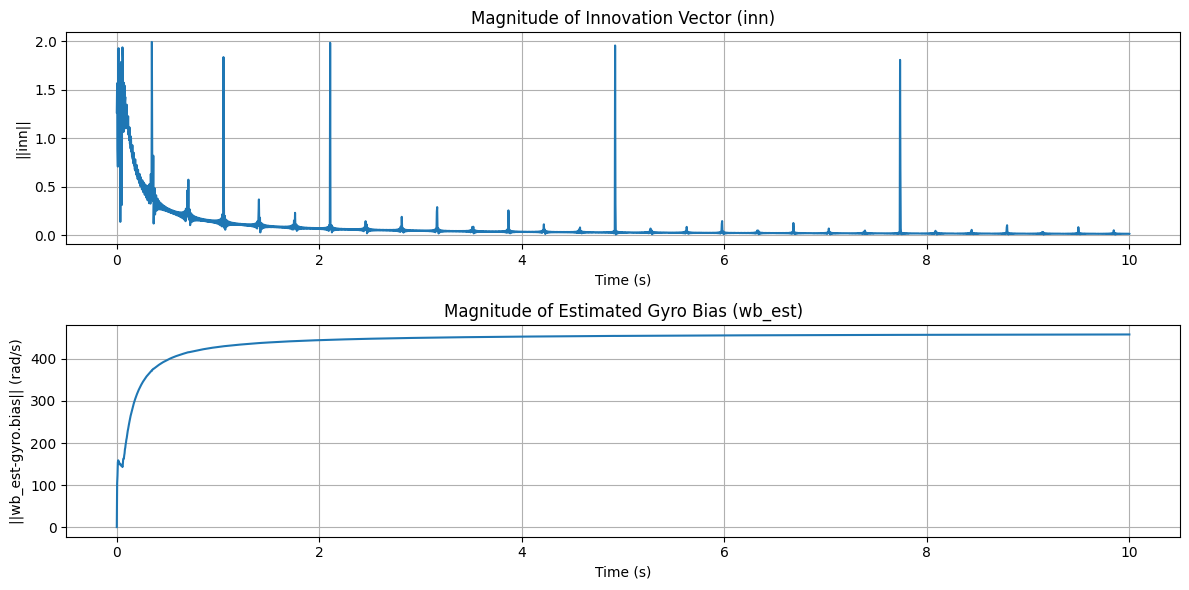

In [ ]:
time_steps = np.arange(0, Tf, dt)

# Calculate the norm for each time step
phi_est_norm = np.linalg.norm(phi_est, axis=1)
wb_est_norm = np.linalg.norm(wb_est-gyro.bias, axis=1)
inn_norm = np.linalg.norm(inn, axis=1)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(time_steps, inn_norm)
plt.title('Magnitude of Innovation Vector (inn)')
plt.xlabel('Time (s)')
plt.ylabel('||inn||')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_steps, wb_est_norm)
plt.title('Magnitude of Estimated Gyro Bias (wb_est)')
plt.xlabel('Time (s)')
plt.ylabel('||wb_est-gyro.bias|| (rad/s)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Particle Filters**

Reference:

https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/master/12-Particle-Filters.ipynb

Chapter 8 of "Probabilistic robotcs, Thrun"

In [ ]:
def create_uniform_particles(x_range, y_range, hdg_range, N):
  '''Uniform distributin of particles
  x_range: (min, max)
  y_range: (min, max)
  hdg_range: (min, max)
  N: number of particles
  '''
  particles = np.empty((N, 3))
  particles[:, 0] = np.random.uniform(x_range[0], x_range[1], size=N)
  particles[:, 1] = np.random.uniform(y_range[0], y_range[1], size=N)
  particles[:, 2] = np.random.uniform(hdg_range[0], hdg_range[1], size=N)
  particles[:, 2] %= 2 * np.pi
  weights = np.ones(N)/N
  return particles,weights

def plot_particles(particles):
  #plt.scatter(particles[:,0],particles[:,1],s=0.1,color='r')
  X = particles[:,0]
  Y = particles[:,1]
  U = np.cos(particles[:,2])
  V = np.sin(particles[:,2])

  plt.quiver(X, Y, U, V, particles[:,2], cmap='viridis', scale_units='xy', scale=10.0, pivot='middle')
  plt.colorbar(label='Angle (radians)')

  plt.show()


def plot_scatter(particles, x_range, y_range):
  #scaletter plot the particles as tiny arrows pointing in heading direction
  # Calculate U and V components for the arrows from the angle
  # U = cos(angle), V = sin(angle)
  X = particles[:,0]
  Y = particles[:,1]
  U = np.cos(particles[:,2])
  V = np.sin(particles[:,2])

  #plt.figure(figsize=(8, 8))
  plt.quiver(X, Y, U, V, particles[:,2], cmap='viridis', scale_units='xy', scale=50.0, pivot='middle') # Corrected here too

  #plt.title('Arrows on a 1x1 Grid (Direction by Angle)')
  #plt.xlabel('X-coordinate')
  #plt.ylabel('Y-coordinate')
  #plt.xlim(x_range)
  #plt.ylim(y_range)
  plt.gca().set_aspect('equal', adjustable='box') # Ensure equal aspect ratio
  plt.colorbar(label='Angle (radians)')
  #plt.grid(True, linestyle='--')
  plt.show()

In [ ]:
def predict_particles(particles, u, std, dt=0.1):
  """
  Sample next state of each particle according control input
  particle: numpy array of particles with (x,y,ang)
  u : control input(u[0]:linear speed, u[1]: angular speed)
  std: std. deviation of process noise (std[0]: dist, std[1]: ang)
  dt: time step
  returns updated list of particles
  """

  N = len(particles)
  # update heading
  particles[:, 2] += u[1]*dt + (np.random.randn(N) * std[1])
  particles[:, 2] %= 2 * np.pi

  # move each in the (noisy) commanded direction
  dist = (u[0] * dt) + (np.random.randn(N) * std[0])
  particles[:, 0] += np.cos(particles[:, 2]) * dist
  particles[:, 1] += np.sin(particles[:, 2]) * dist
  return particles



def update_true_pose(pose,u, dt=0.1,std=np.array([0.0,0.0])):
  '''update the true pose
  pose: (x,y,ang)
  u: ([0]: linear velocity, [1] angular velocity)
  std: ([0]: linear velocity std. dev., [1]: angular velocity std. dev.)
  dt: time step
  return:
  updated pose
  '''
  # update heading
  pose[2] += (u[1]+np.random.normal(0,std[1]))*dt
  pose[2] %= 2 * np.pi

  # move in the commanded direction
  dist = (u[0]+np.random.normal(0,std[0])) * dt
  pose[0] += np.cos(pose[2]) * dist
  pose[1] += np.sin(pose[2]) * dist
  return pose

def make_measurements(pose, mapL, dist_range=4.0, R=np.array([0.0,0.0])):
  '''
  make measurements of the landmarks from the given pose
  pose: current pose
  mapL: list of landmarks (x,y) with their ids
  dist_range: only landmarks within dist_range of pose will be measured
  R: Measurement std deviation (distance, angle), with zero mean gaussian

  return
  Z: (x, y, ang, landmark id) of measurements
  '''
  Z=[]
  dstd=R[0]
  astd=R[1]
  for lid in mapL: #iterate through all landmarks
    lx,ly = mapL[lid]
    if (np.linalg.norm(pose[0:2]-np.array([lx,ly])) < dist_range):
      #landmark within measurement range
      ang = np.arctan2(ly-pose[1],lx-pose[0])-pose[2] + (np.random.randn() * astd)
      if (ang > np.pi):
        ang -= 2*np.pi
      elif (ang < -np.pi):
        ang += 2*np.pi
      dist = np.linalg.norm(pose[0:2]-np.array([lx,ly])) + (np.random.randn() * dstd)
      Z.append([dist,ang,lid])
  return np.array(Z)

100: pose=[1.70710678 1.70710678 0.78539816],Z=[[ 1.84775907 -2.74889357  0.        ]
 [ 1.73205081 -2.18627604  1.        ]
 [ 1.84775907  2.74889357  3.        ]
 [ 1.73205081  2.18627604  4.        ]
 [ 2.85859631  1.42538338  5.        ]]
200: pose=[2.41421356 2.41421356 0.78539816],Z=[[ 2.79793265 -2.88609728  0.        ]
 [ 2.44948974 -2.52611294  1.        ]
 [ 2.79793265  2.88609728  3.        ]
 [ 2.44948974  2.52611294  4.        ]
 [ 2.88845041  1.7750159   5.        ]]
300: pose=[3.12132034 3.12132034 0.78539816],Z=[[ 3.77394233 -2.95311314  0.        ]
 [ 3.31662479 -2.70108199  1.        ]
 [ 3.77394233  2.95311314  3.        ]
 [ 3.31662479  2.70108199  4.        ]
 [ 3.24264069  2.08178707  5.        ]]
400: pose=[3.82842712 3.82842712 0.78539816],Z=[[3.83226976 2.31140896 5.        ]]
500: pose=[4.53553391 4.53553391 0.78539816],Z=[]
600: pose=[5.24264069 5.24264069 0.78539816],Z=[]
700: pose=[5.94974747 5.94974747 0.78539816],Z=[]
800: pose=[6.65685425 6.65685425 0.78

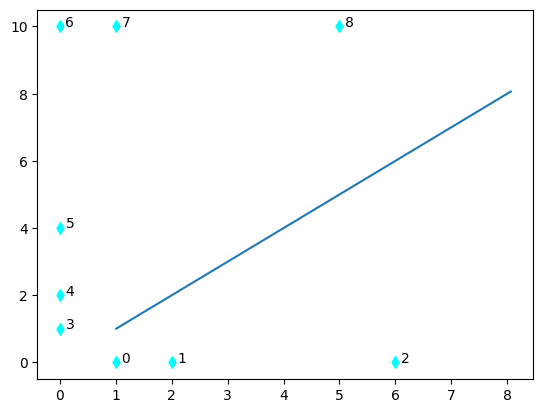

In [ ]:
#list of landmarks
mapL={
    0:[1,0],
    1:[2,0],
    2:[6,0],
    3:[0,1],
    4:[0,2],
    5:[0,4],
    6:[0,10],
    7:[1,10],
    8:[5,10]
}

dt=0.1 #s of time step
NT=1000 # time steps of each of size dt

pose = np.zeros((NT,3))
pose[0]=(1,1,np.pi/4) #initially pointing along diagonal

u = (0.1,0) #go in a straight line withe speed of 1m/s

for i in np.arange(1,NT):
  pose[i] = update_true_pose(pose[i-1],u,dt)
  Z = make_measurements(pose[i],mapL)
  if i % 100 == 0:
    print(f"{i}: pose={pose[i]},Z={Z}")

fig,ax = plt.subplots()
lmrk = np.array(list(mapL.values()))
ax.scatter(lmrk[:,0],lmrk[:,1],marker="d",c="cyan")
for lid in mapL:
  ax.annotate(str(lid), (mapL[lid][0]+0.1,mapL[lid][1]))
ax.plot(pose[:,0],pose[:,1])
plt.show()

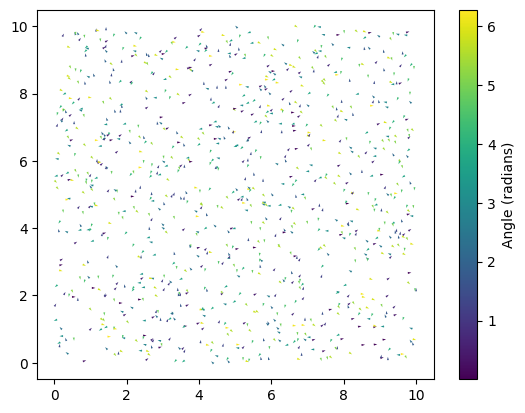

In [ ]:
u = (0.1,0) #go in a straight line withe speed of 1m/s
dstd = 0.1
astd = 0.01
R = np.array([dstd,astd])

#Number of particles
NP =1000

#number of simulation time steps
NT = 2

pose = np.zeros((NT,3))
pose[0]=(1,1,np.pi/4) #initially pointing along diagonal

u = (0.1,0) #go in a straight line withe speed of 1m/s

#create particles and weights
particles,weights = create_uniform_particles((0,10),(0,10),(0,2*np.pi),NP)
particles[0] = pose[0]
plot_particles(particles)
#print(particles)

In [ ]:
def simple_resample(particles, weights):
  N = len(particles)
  cumulative_sum = np.cumsum(weights)
  cumulative_sum[-1] = 1. # avoid round-off error
  indexes = np.searchsorted(cumulative_sum, np.random.random(N))
  return indexes


def Neff(weights):
  '''
  return effective number of particles, calculated
  as a function of inverse sum of weights square
  '''
  return 1.0/np.sum(np.square(weights))

def resample_from_index(particles, weights, indexes):
  particles[:] = particles[indexes]
  weights.resize(len(particles))
  weights.fill(1.0 / len(weights))
  return particles, weights

def moments(particles, weights):
  '''
  return the mean and covariance of the weighted particles
  '''
  mean = np.average(particles, weights=weights, axis=0)
  cov = np.average((particles - mean)**2, weights=weights, axis=0) #not quite correct
  return mean, cov

**Q8**

Complete the functions below

In [ ]:
def low_variance_resample(particles, weights):
  N = len(weights)
  #<your code here>

  # make N subdivisions, choose positions
  # with a consistent random offset
  positions = (np.arange(N) + np.random.random()) / N

  indexes = np.zeros(N, 'i')
  cumulative_sum = np.cumsum(weights)
  i, j = 0, 0
  while i < N:
    if positions[i] < cumulative_sum[j]:
      indexes[i] = j
      i += 1
    else:
      j += 1
  return indexes

def adaptive_low_variance_resample(particles, weights, wslow, wfast):
  #<your code here>

  return indexes

def update_particle_weights(particles, weights, Z, R, mapL):
  '''
  update the weights with measurement likelihood
  particles: Nx3 array of particles with x,y, ang
  weights: Nx1 array of weight for each particle
  Z: M x 3 (range, ang, landmark id) is the set of measurements
  R: measurement noise covariance R[0]: distance cov, R[1]: ang covariance
  mapL: L x 2 (lx, ly) location of landmarks in the map
  returns
  updated weights (multiplied by likelihood)
  '''


  #for each measurement
  for zdist,zang,zid in Z:
    #<your code>

    lx,ly = mapL[zid]
    distances = np.linalg.norm(particles[:, 0:2] - np.array([lx,ly]), axis=1)
    angles = np.arctan2(ly - particles[:, 1], lx - particles[:, 0])
    angles -= particles[:, 2]
    angles = np.where(angles> np.pi, angles-2*np.pi, angles)
    angles = np.where(angles<-np.pi, angles+2*np.pi, angles)
    lkl_dist=scipy.stats.norm(distances, R[0]).pdf(zdist)
    weights *= lkl_dist
    lkl_ang=scipy.stats.norm(angles, R[1]).pdf(zang)
    weights *= lkl_ang
  #end for
  weights += 1.e-16  # avoid round-off to zero
  weights /= sum(weights)

  return weights

**Q9**

Complete the code to simulate tracking/localization

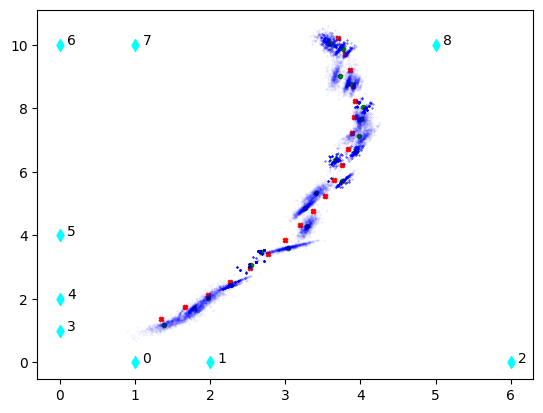

In [ ]:
NP=1000 #number of particles
NT=1000 #number of time steps for simulation
dt=0.1 #time step

u = (0.1,0.01) #go in a curve with speed of 1m/s
pstd = np.array([0.1,0.1]) #lin, ang std. dev.  for actual motion

P = np.array([0.1,0.1]) #linear, angular std deviation for process model

R = np.array([0.5,0.5]) #distance, angle std deviation for measurement


fig,ax = plt.subplots()
lmrk = np.array(list(mapL.values()))
ax.scatter(lmrk[:,0],lmrk[:,1],marker="d",c="cyan")
for lid in mapL:
  ax.annotate(str(lid), (mapL[lid][0]+0.1,mapL[lid][1]))


#True pose trajectory of the robot
pose = np.zeros((NT+1,3))
pose[0]=(1,1,np.pi/4) #initially pointing along diagonal

particles,weights = create_uniform_particles((0,10),(0,10),(0,2*np.pi),NP)

#average of slow/fast weights for adaptive resampling
wslow = np.average(weights)
wfast = np.average(weights)
a_slow=1/100.0
a_fast=1/10.0

#mean of the estimated pose
mean = np.zeros((NT+1,3))
mean[0],_ = moments(particles,weights) #mean is obtained from the particles

#simulate the robot motion and measurements
for i in np.arange(0,NT):

  #move the robot and make measurements
  pose[i+1] = update_true_pose(pose[i],u,dt)
  Z = make_measurements(pose[i+1],mapL,dist_range=10.0, R=R)


  #<your code> to update the particles
  particles = predict_particles(particles,u,std=P,dt=dt)
  weights = update_particle_weights(particles, weights, Z, R=R, mapL=mapL)
  mean[i+1],_ = moments(particles,weights)

  #updated weights
  wslow = wslow + a_slow*(wslow-np.average(weights))
  wfast = wfast + a_fast*np.average(weights)

  #<Your code for resampling>
  if (Neff(weights) < NP/3): #increase diversity of particles by resampling
    #indexes = simple_resample(particles,weights)
    indexes = low_variance_resample(particles,weights)
    #indexes = adaptive_low_variance_resample(particles,weights,wslow, wfast)
    particles,weights = resample_from_index(particles,weights,indexes)

  #Plot the true pose (Red) estimated mean pose (green), particle cloud (blue)
  if ((i+1) % 50 == 0): #plot
    ax.scatter(pose[i+1,0],pose[i+1,1],s=10.0,marker="X", c="r")
    ax.scatter(mean[i+1,0],mean[i+1,1],s=10.0,marker="P", c="g")
    ax.scatter(particles[:,0],particles[:,1],s=0.1,c='b',alpha=0.1)

#plot the final estimate pose and particle cloud.
#ax.scatter(pose[-1,0],pose[-1,1],s=10.0,marker="X", c="r")
ax.scatter(mean[-1,0],mean[-1,1],s=10.0,marker="P", c="g")educational
ax.scatter(particles[:,0],particles[:,1],s=0.1,c='b',alpha=0.1)
plt.show()

In [ ]:
#@title Instructor: run this cell once you are happy with this notebook rubric to upload the rubric. Remember to delete this cell when you make a copy to be shared with the students for their quiz. The copy will contain the next cell which will allow the students to submit their notebook for evaluation.
ta.upload_rubric(session,AI_TA_URL, notebook_id, course_id,term_id, institution_id)

In [ ]:
#@title SUBMISSION: Students: run this cell to submit your notebook for evaluation. It might take a bit of time - dont panic! As a backup share the notebook link with your instructor. Make sure the note book is readable by them.
ta.show_submit_eval_button(session,AI_TA_URL, notebook_id, institution_id, term_id, course_id)